# 🔍 Fairness-Preserving Lightweight Deepfake Detection
### Full Training & Evaluation Pipeline
This notebook automates every step of the research pipeline:
1. Environment & GPU check
2. Dataset statistics & demographic distribution
3. Teacher training (XceptionNet)
4. Baseline student training (MobileNetV2)
5. Fairness-aware distillation (our method)
6. Standard distillation (ablation)
7. Comprehensive evaluation + fairness metrics
8. Cross-dataset generalization
9. Ablation comparison tables
10. Per-group accuracy & ROC charts
11. Grad-CAM heatmaps
12. Model size & speed profiling

## ⚙️ Cell 0 — Setup & Imports

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = r'D:\M3 Projects\DeepFake_Research'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
from torch.utils.data import DataLoader

from src.config import (
    DEVICE, SPLITS_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, GRADCAM_DIR,
    DEMOGRAPHIC_GROUPS, BATCH_SIZE, NUM_WORKERS,
    DISTILL_EPOCHS, STUDENT_EPOCHS, TEACHER_EPOCHS,
    ALPHA, BETA, GAMMA, DISTILL_TEMPERATURE
)
from src.models.xception import build_teacher
from src.models.mobilenetv2 import build_student
from src.data.dataset import create_dataloaders, DeepfakeDataset
from src.evaluation.evaluate import evaluate_model, save_results, compare_models
from src.evaluation.cross_dataset import run_full_cross_dataset_evaluation

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
COLORS = sns.color_palette('husl', 8)

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print('✅ Imports OK')

## 🖥️ Cell 1 — GPU Check & Config

In [2]:
print('='*55)
print('  ENVIRONMENT')
print('='*55)
print(f'  PyTorch:      {torch.__version__}')
print(f'  CUDA:         {torch.version.cuda}')
print(f'  Device:       {DEVICE}')

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'  GPU:          {gpu.name}')
    print(f'  VRAM:         {gpu.total_memory/1e9:.1f} GB')
    print(f'  CUDA cores:   {gpu.multi_processor_count} SMs')
else:
    print('  ⚠️  No GPU — training will be slow!')

print('='*55)
print('  TRAINING CONFIG')
print('='*55)
print(f'  Batch size:   {BATCH_SIZE}')
print(f'  Distill α:    {ALPHA}  (distillation loss weight)')
print(f'  Distill β:    {BETA}  (fairness loss weight)')
print(f'  Distill γ:    {GAMMA}  (classification loss weight)')
print(f'  Temperature:  {DISTILL_TEMPERATURE}')
print(f'  Groups:       {DEMOGRAPHIC_GROUPS}')

# Stability settings for RTX 4050 on Windows
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
print('cuDNN deterministic mode: ON')

  ENVIRONMENT
  PyTorch:      2.6.0+cu124
  CUDA:         12.4
  Device:       cuda
  GPU:          NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM:         6.4 GB
  CUDA cores:   20 SMs
  TRAINING CONFIG
  Batch size:   32
  Distill α:    0.7  (distillation loss weight)
  Distill β:    0.2  (fairness loss weight)
  Distill γ:    0.1  (classification loss weight)
  Temperature:  4.0
  Groups:       ['Male-White', 'Male-Black', 'Male-Asian', 'Male-Other', 'Female-White', 'Female-Black', 'Female-Asian', 'Female-Other']
cuDNN deterministic mode: ON


## 📊 Cell 2 — Dataset Statistics & Demographic Distribution

Split sizes:
  train :  146,871 total  (20,970 real / 125,901 fake)
  val   :   31,487 total  (4,500 real / 26,987 fake)
  test  :   31,474 total  (4,527 real / 26,947 fake)
  Celeb-DF:  195,829 total (cross-dataset test)
  DFD     :  102,359 total (cross-dataset test)


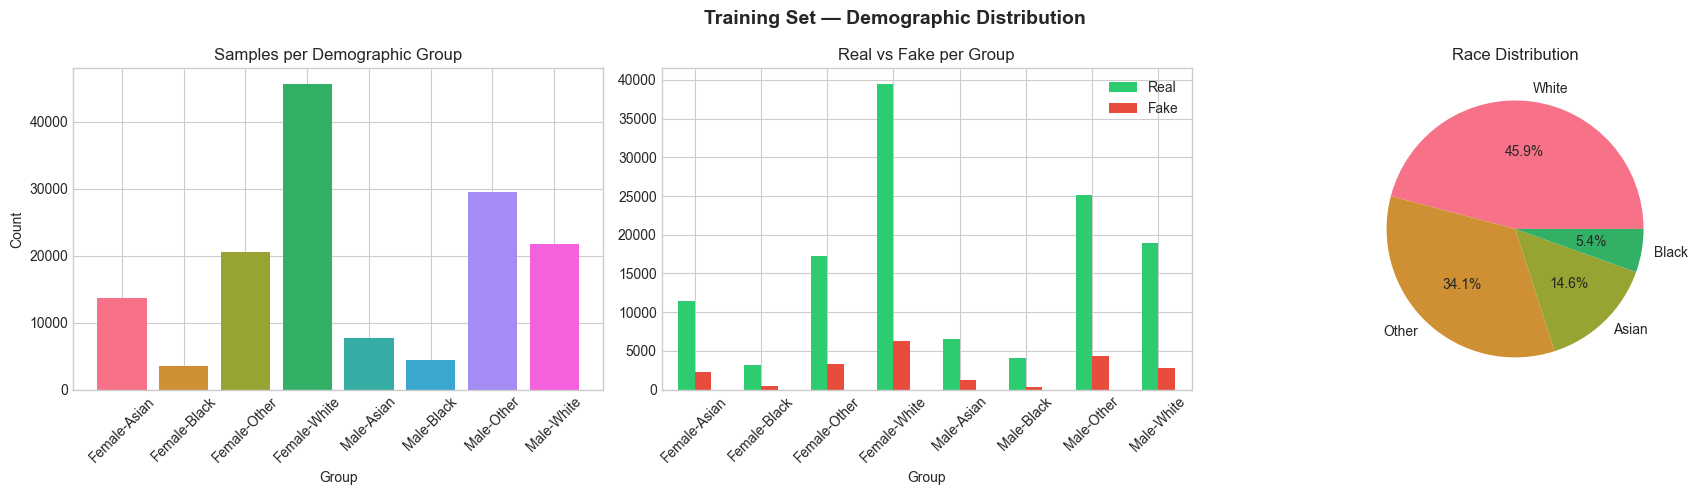

✅ Dataset stats plotted


In [3]:
splits = {}
for split in ['train', 'val', 'test']:
    path = os.path.join(SPLITS_DIR, f'{split}.csv')
    splits[split] = pd.read_csv(path)

print('Split sizes:')
for name, df in splits.items():
    real = (df['label']=='REAL').sum()
    fake = (df['label']=='FAKE').sum()
    print(f'  {name:6s}: {len(df):>8,} total  ({real:,} real / {fake:,} fake)')

# Cross-dataset sizes
for ds in ['Celeb-DF', 'DFD']:
    p = os.path.join(SPLITS_DIR, f'{ds}_test.csv')
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'  {ds:8s}: {len(df):>8,} total (cross-dataset test)')

train_df = splits['train']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Set — Demographic Distribution', fontsize=14, fontweight='bold')

# 1. Group distribution
grp_counts = train_df['demographic_group'].value_counts().sort_index()
axes[0].bar(grp_counts.index, grp_counts.values, color=COLORS)
axes[0].set_title('Samples per Demographic Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 2. Real vs Fake per group
grp_label = train_df.groupby(['demographic_group', 'label']).size().unstack(fill_value=0)
grp_label.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Real vs Fake per Group')
axes[1].set_xlabel('Group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Real', 'Fake'])

# 3. Race & Gender pie charts
race_counts = train_df['race'].value_counts()
axes[2].pie(race_counts.values, labels=race_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(race_counts)])
axes[2].set_title('Race Distribution')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dataset stats plotted')

## 🎓 Cell 3 — Train Teacher (XceptionNet)
> Skips automatically if checkpoint already exists.

In [4]:
from src.training.train_baseline import train_baseline

TEACHER_WEIGHTS = os.path.join(MODELS_DIR, 'xception_teacher_best.pth')
TEACHER_EPOCHS_NB = 20   # ← change as needed
TEACHER_BATCH   = 64    # ← optimized for RTX 4050 6GB

if os.path.exists(TEACHER_WEIGHTS):
    print(f'✅ Teacher checkpoint found — skipping training.')
    ckpt = torch.load(TEACHER_WEIGHTS, map_location=DEVICE, weights_only=False)
    print(f'   Saved at epoch {ckpt["epoch"]+1}, val AUC = {ckpt["val_auc"]:.4f}')
else:
    print('🚀 Training Teacher (XceptionNet)...')
    teacher = build_teacher(pretrained=True, device=DEVICE)
    loaders = create_dataloaders(
        os.path.join(SPLITS_DIR, 'train.csv'),
        os.path.join(SPLITS_DIR, 'val.csv'),
        batch_size=TEACHER_BATCH,
        num_workers=12
    )
    optimizer = torch.optim.AdamW(teacher.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TEACHER_EPOCHS_NB)
    results = train_baseline(
        teacher, loaders['train'], loaders['val'],
        optimizer, scheduler,
        num_epochs=TEACHER_EPOCHS_NB,
        model_name='xception_teacher',
        device=DEVICE
    )
    print(f'\n✅ Teacher training done. Best AUC: {results["best_auc"]:.4f}')




## 📱 Cell 4 — Train Baseline Student (MobileNetV2, no distillation)
> Skips if checkpoint exists. This is our ablation baseline.

In [5]:
BASELINE_WEIGHTS = os.path.join(MODELS_DIR, 'mobilenetv2_baseline_best.pth')
BASELINE_EPOCHS  = 50    # ← change as needed
BASELINE_BATCH   = 128   # ← optimized for RTX 4050 6GB

if os.path.exists(BASELINE_WEIGHTS):
    print(f'✅ Baseline student checkpoint found — skipping training.')
    ckpt = torch.load(BASELINE_WEIGHTS, map_location=DEVICE, weights_only=False)
    print(f'   Saved at epoch {ckpt["epoch"]+1}, val AUC = {ckpt["val_auc"]:.4f}')
else:
    print('🚀 Training Baseline Student (MobileNetV2, no distillation)...')
    baseline_student = build_student(pretrained=True, device=DEVICE)
    loaders = create_dataloaders(
        os.path.join(SPLITS_DIR, 'train.csv'),
        os.path.join(SPLITS_DIR, 'val.csv'),
        batch_size=BASELINE_BATCH,
        num_workers=12
    )
    optimizer = torch.optim.AdamW(baseline_student.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=BASELINE_EPOCHS, eta_min=1e-6)
    results = train_baseline(
        baseline_student, loaders['train'], loaders['val'],
        optimizer, scheduler,
        num_epochs=BASELINE_EPOCHS,
        model_name='mobilenetv2_baseline',
        device=DEVICE
    )
    print(f'\n✅ Baseline training done. Best AUC: {results["best_auc"]:.4f}')




## ⚖️ Cell 5 — Train Fair Student (Fairness-Aware Distillation) — OUR METHOD
> Core contribution. Skips if checkpoint exists.

In [6]:
from src.training.train_distill import train_fair_distillation

FAIR_WEIGHTS  = os.path.join(MODELS_DIR, 'fair_student_best_auc.pth')
FAIR_EPOCHS   = 50    # ← change as needed
FAIR_BATCH    = 32    # ← distillation: teacher+student both in VRAM
FAIR_ALPHA    = 0.7   # distillation loss weight
FAIR_BETA     = 0.2   # fairness loss weight  ← our novel term
FAIR_GAMMA    = 0.1   # classification loss weight

if os.path.exists(FAIR_WEIGHTS):
    print(f'✅ Fair student checkpoint found — skipping training.')
    ckpt = torch.load(FAIR_WEIGHTS, map_location=DEVICE, weights_only=False)
    print(f'   Saved at epoch {ckpt["epoch"]+1}, val AUC = {ckpt["val_auc"]:.4f}')
    print(f'   Val metrics: {ckpt.get("val_metrics", {})}')
else:
    print('🚀 Training Fair Student (Fairness-Aware Distillation)...')
    print(f'   Loss: {FAIR_ALPHA}·L_distill + {FAIR_BETA}·L_fairness + {FAIR_GAMMA}·L_cls')

    # Load teacher
    teacher = build_teacher(pretrained=True, device=DEVICE)
    ckpt = torch.load(TEACHER_WEIGHTS, map_location=DEVICE, weights_only=False)
    teacher.load_state_dict(ckpt['model_state_dict'])
    print(f'   Teacher loaded (val AUC={ckpt["val_auc"]:.4f})')

    # Fresh student
    fair_student = build_student(pretrained=True, device=DEVICE)

    loaders = create_dataloaders(
        os.path.join(SPLITS_DIR, 'train.csv'),
        os.path.join(SPLITS_DIR, 'val.csv'),
        batch_size=FAIR_BATCH,
        fair_sampling=True
    )
    optimizer = torch.optim.AdamW(fair_student.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    results = train_fair_distillation(
        fair_student, teacher,
        loaders['train'], loaders['val'],
        optimizer, scheduler,
        num_epochs=FAIR_EPOCHS,
        alpha=FAIR_ALPHA, beta=FAIR_BETA, gamma=FAIR_GAMMA,
        temperature=DISTILL_TEMPERATURE,
        model_name='fair_student',
        device=DEVICE
    )
    print(f'\n✅ Fair distillation done.')
    print(f'   Best AUC:          {results["best_auc"]:.4f}')
    print(f'   Best Fairness Gap: {results["best_fairness_gap"]:.4f}')

🚀 Training Fair Student (Fairness-Aware Distillation)...
   Loss: 0.7·L_distill + 0.2·L_fairness + 0.1·L_cls
[Teacher] XceptionNet loaded:
  Total params:     21.9M
  Trainable params: 21.9M
  Model size:       83.6 MB
   Teacher loaded (val AUC=0.9671)
[Student] MobileNetV2 loaded:
  Total params:     2.6M
  Trainable params: 2.6M
  Model size:       9.9 MB
[Dataset] Loaded 146871 samples for train
  REAL: 20970, FAKE: 125901
[Dataset] Loaded 31487 samples for val
  REAL: 4500, FAKE: 26987

Fairness-Aware Knowledge Distillation
  Student: fair_student
  Loss: α=0.7·Ld + β=0.2·Lf + γ=0.1·Lc
  Temperature: 4.0, Epochs: 50
  AMP (fp16): ✅ ON



Epoch [1/50] (1333.8s) β=0.2000
  Train — Loss: 1.7215 (Ld:2.395 Lf:0.095 Lc:0.262)
  Train — Acc: 0.9174, AUC: 0.9389
  Val   — Acc: 0.9034, AUC: 0.9453, AccGap: 0.0656
    Female-Asian        : 0.9253
    Female-Black        : 0.9241
    Female-Other        : 0.9034
    Female-White        : 0.8935
    Male-Asian          : 0.9073
    Male-Black          : 0.9572
    Male-Other          : 0.8916
    Male-White          : 0.9114
  ★ Best AUC: 0.9453 — saved
  ★ Best Fairness (gap=0.0656) — saved



Epoch [2/50] (1346.9s) β=0.2000
  Train — Loss: 0.9276 (Ld:1.286 Lf:0.066 Lc:0.146)
  Train — Acc: 0.9537, AUC: 0.9811
  Val   — Acc: 0.9168, AUC: 0.9472, AccGap: 0.0756
    Female-Asian        : 0.9383
    Female-Black        : 0.9555
    Female-Other        : 0.9064
    Female-White        : 0.9036
    Male-Asian          : 0.9127
    Male-Black          : 0.9792
    Male-Other          : 0.9174
    Male-White          : 0.9244
  ★ Best AUC: 0.9472 — saved



Epoch [3/50] (1345.4s) β=0.2000
  Train — Loss: 0.7343 (Ld:1.017 Lf:0.055 Lc:0.118)
  Train — Acc: 0.9637, AUC: 0.9875
  Val   — Acc: 0.9190, AUC: 0.9491, AccGap: 0.0484
    Female-Asian        : 0.9295
    Female-Black        : 0.9542
    Female-Other        : 0.9148
    Female-White        : 0.9258
    Male-Asian          : 0.9154
    Male-Black          : 0.9550
    Male-Other          : 0.9073
    Male-White          : 0.9066
  ★ Best AUC: 0.9491 — saved
  ★ Best Fairness (gap=0.0484) — saved



Epoch [4/50] (1343.1s) β=0.2000
  Train — Loss: 0.6210 (Ld:0.859 Lf:0.048 Lc:0.101)
  Train — Acc: 0.9693, AUC: 0.9904
  Val   — Acc: 0.9235, AUC: 0.9514, AccGap: 0.0784
    Female-Asian        : 0.9485
    Female-Black        : 0.9437
    Female-Other        : 0.9163
    Female-White        : 0.9207
    Male-Asian          : 0.9224
    Male-Black          : 0.9923
    Male-Other          : 0.9140
    Male-White          : 0.9176
  ★ Best AUC: 0.9514 — saved



...

Epoch [12/50] (1349.8s) β=0.2000
  Train — Loss: 0.3685 (Ld:0.508 Lf:0.034 Lc:0.062)
  Train — Acc: 0.9812, AUC: 0.9956
  Val   — Acc: 0.9218, AUC: 0.9426, AccGap: 0.0929
    Female-Asian        : 0.9299
    Female-Black        : 0.8940
    Female-Other        : 0.9310
    Female-White        : 0.9232
    Male-Asian          : 0.9407
    Male-Black          : 0.9868
    Male-Other          : 0.9075
    Male-White          : 0.9082



Epoch [13/50] (1349.4s) β=0.2000
  Train — Loss: 0.2893 (Ld:0.398 Lf:0.029 Lc:0.049)
  Train — Acc: 0.9850, AUC: 0.9969
  Val   — Acc: 0.9254, AUC: 0.9488, AccGap: 0.0467
    Female-Asian        : 0.9489
    Female-Black        : 0.9359
    Female-Other        : 0.9313
    Female-White        : 0.9217
    Male-Asian          : 0.9332
    Male-Black          : 0.9616
    Male-Other          : 0.9149
    Male-White          : 0.9152
  ★ Best Fairness (gap=0.0467) — saved



Epoch [14/50] (1349.3s) β=0.2000
  Train — Loss: 0.2696 (Ld:0.371 Lf:0.028 Lc:0.046)
  Train — Acc: 0.9860, AUC: 0.9971
  Val   — Acc: 0.9219, AUC: 0.9403, AccGap: 0.0589
    Female-Asian        : 0.9263
    Female-Black        : 0.9188
    Female-Other        : 0.9299
    Female-White        : 0.9249
    Male-Asian          : 0.9402
    Male-Black          : 0.9638
    Male-Other          : 0.9106
    Male-White          : 0.9049



Epoch [15/50] (1349.3s) β=0.2000
  Train — Loss: 0.2607 (Ld:0.358 Lf:0.027 Lc:0.044)
  Train — Acc: 0.9863, AUC: 0.9973
  Val   — Acc: 0.9182, AUC: 0.9407, AccGap: 0.0707
    Female-Asian        : 0.9232
    Female-Black        : 0.9215
    Female-Other        : 0.9240
    Female-White        : 0.9222
    Male-Asian          : 0.9348
    Male-Black          : 0.9660
    Male-Other          : 0.8954
    Male-White          : 0.9147



Epoch [16/50] (1345.1s) β=0.2000
  Train — Loss: 0.2475 (Ld:0.340 Lf:0.027 Lc:0.044)
  Train — Acc: 0.9864, AUC: 0.9975
  Val   — Acc: 0.9205, AUC: 0.9389, AccGap: 0.0620
    Female-Asian        : 0.9151
    Female-Black        : 0.9123
    Female-Other        : 0.9247
    Female-White        : 0.9238
    Male-Asian          : 0.9327
    Male-Black          : 0.9715
    Male-Other          : 0.9128
    Male-White          : 0.9095

Early stopping at epoch 16

Fair distillation complete.
  Best AUC: 0.9565
  Best Fairness Gap: 0.0467

✅ Fair distillation done.
   Best AUC:          0.9565
   Best Fairness Gap: 0.0467


## 🔬 Cell 6 — Train Standard Distillation (Ablation — β=0, no fairness loss)
> Needed for the ablation table. Skips if checkpoint exists.

In [7]:
STD_WEIGHTS = os.path.join(MODELS_DIR, 'std_distill_student_best_auc.pth')
STD_EPOCHS  = 50
STD_BATCH   = 32     # ← distillation: teacher+student both in VRAM

if os.path.exists(STD_WEIGHTS):
    print(f'✅ Standard distillation checkpoint found — skipping.')
    ckpt = torch.load(STD_WEIGHTS, map_location=DEVICE, weights_only=False)
    print(f'   Saved at epoch {ckpt["epoch"]+1}, val AUC = {ckpt["val_auc"]:.4f}')
else:
    print('🚀 Training Standard Distillation student (β=0, no fairness loss)...')

    teacher = build_teacher(pretrained=True, device=DEVICE)
    ckpt = torch.load(TEACHER_WEIGHTS, map_location=DEVICE, weights_only=False)
    teacher.load_state_dict(ckpt['model_state_dict'])

    std_student = build_student(pretrained=True, device=DEVICE)
    loaders = create_dataloaders(
        os.path.join(SPLITS_DIR, 'train.csv'),
        os.path.join(SPLITS_DIR, 'val.csv'),
        batch_size=STD_BATCH,
        fair_sampling=True
    )
    optimizer = torch.optim.AdamW(std_student.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    torch.cuda.empty_cache()
    results = train_fair_distillation(
        std_student, teacher,
        loaders['train'], loaders['val'],
        optimizer, scheduler,
        num_epochs=STD_EPOCHS,
        alpha=0.9, beta=0.0, gamma=0.1,   # ← β=0: no fairness constraint
        temperature=DISTILL_TEMPERATURE,
        model_name='std_distill_student',
        device=DEVICE
    )
    print(f'\n✅ Standard distillation done. Best AUC: {results["best_auc"]:.4f}')

🚀 Training Standard Distillation student (β=0, no fairness loss)...
[Teacher] XceptionNet loaded:
  Total params:     21.9M
  Trainable params: 21.9M
  Model size:       83.6 MB
[Student] MobileNetV2 loaded:
  Total params:     2.6M
  Trainable params: 2.6M
  Model size:       9.9 MB
[Dataset] Loaded 146871 samples for train
  REAL: 20970, FAKE: 125901
[Dataset] Loaded 31487 samples for val
  REAL: 4500, FAKE: 26987

Fairness-Aware Knowledge Distillation
  Student: std_distill_student
  Loss: α=0.9·Ld + β=0.0·Lf + γ=0.1·Lc
  Temperature: 4.0, Epochs: 50
  AMP (fp16): ✅ ON



Epoch [1/50] (1337.0s) β=0.0000
  Train — Loss: 2.1996 (Ld:2.415 Lf:0.095 Lc:0.263)
  Train — Acc: 0.9177, AUC: 0.9384
  Val   — Acc: 0.8897, AUC: 0.9394, AccGap: 0.1120
    Female-Asian        : 0.9225
    Female-Black        : 0.9503
    Female-Other        : 0.8926
    Female-White        : 0.8971
    Male-Asian          : 0.8572
    Male-Black          : 0.9616
    Male-Other          : 0.8496
    Male-White          : 0.8937
  ★ Best AUC: 0.9394 — saved
  ★ Best Fairness (gap=0.1120) — saved



Epoch [2/50] (1339.3s) β=0.0000
  Train — Loss: 1.1861 (Ld:1.301 Lf:0.065 Lc:0.150)
  Train — Acc: 0.9530, AUC: 0.9803
  Val   — Acc: 0.9031, AUC: 0.9408, AccGap: 0.1365
    Female-Asian        : 0.9228
    Female-Black        : 0.9149
    Female-Other        : 0.9034
    Female-White        : 0.9154
    Male-Asian          : 0.8448
    Male-Black          : 0.9814
    Male-Other          : 0.8742
    Male-White          : 0.9095
  ★ Best AUC: 0.9408 — saved



Epoch [3/50] (1343.2s) β=0.0000
  Train — Loss: 0.9259 (Ld:1.015 Lf:0.056 Lc:0.120)
  Train — Acc: 0.9628, AUC: 0.9873
  Val   — Acc: 0.9161, AUC: 0.9506, AccGap: 0.0936
    Female-Asian        : 0.9299
    Female-Black        : 0.9319
    Female-Other        : 0.9227
    Female-White        : 0.9155
    Male-Asian          : 0.8955
    Male-Black          : 0.9890
    Male-Other          : 0.8971
    Male-White          : 0.9193
  ★ Best AUC: 0.9506 — saved
  ★ Best Fairness (gap=0.0936) — saved



Epoch [4/50] (1339.1s) β=0.0000
  Train — Loss: 0.7866 (Ld:0.863 Lf:0.049 Lc:0.103)
  Train — Acc: 0.9692, AUC: 0.9903
  Val   — Acc: 0.9085, AUC: 0.9431, AccGap: 0.1036
    Female-Asian        : 0.9186
    Female-Black        : 0.9686
    Female-Other        : 0.9148
    Female-White        : 0.9085
    Male-Asian          : 0.8766
    Male-Black          : 0.9803
    Male-Other          : 0.8918
    Male-White          : 0.9071



...

Epoch [9/50] (1338.4s) β=0.0000
  Train — Loss: 0.5370 (Ld:0.589 Lf:0.038 Lc:0.072)
  Train — Acc: 0.9782, AUC: 0.9946
  Val   — Acc: 0.9128, AUC: 0.9464, AccGap: 0.0925
    Female-Asian        : 0.9344
    Female-Black        : 0.8979
    Female-Other        : 0.9181
    Female-White        : 0.9159
    Male-Asian          : 0.9122
    Male-Black          : 0.9857
    Male-Other          : 0.8933
    Male-White          : 0.9022



Epoch [10/50] (1338.7s) β=0.0000
  Train — Loss: 0.4127 (Ld:0.452 Lf:0.032 Lc:0.056)
  Train — Acc: 0.9827, AUC: 0.9962
  Val   — Acc: 0.9230, AUC: 0.9503, AccGap: 0.0618
    Female-Asian        : 0.9415
    Female-Black        : 0.9319
    Female-Other        : 0.9319
    Female-White        : 0.9266
    Male-Asian          : 0.9213
    Male-Black          : 0.9649
    Male-Other          : 0.9031
    Male-White          : 0.9130



Epoch [11/50] (1345.8s) β=0.0000
  Train — Loss: 0.3794 (Ld:0.416 Lf:0.030 Lc:0.052)
  Train — Acc: 0.9842, AUC: 0.9967
  Val   — Acc: 0.9235, AUC: 0.9474, AccGap: 0.0706
    Female-Asian        : 0.9351
    Female-Black        : 0.9372
    Female-Other        : 0.9293
    Female-White        : 0.9238
    Male-Asian          : 0.9186
    Male-Black          : 0.9770
    Male-Other          : 0.9180
    Male-White          : 0.9064



Epoch [12/50] (1333.3s) β=0.0000
  Train — Loss: 0.3562 (Ld:0.390 Lf:0.030 Lc:0.050)
  Train — Acc: 0.9845, AUC: 0.9969
  Val   — Acc: 0.9182, AUC: 0.9342, AccGap: 0.0682
    Female-Asian        : 0.9323
    Female-Black        : 0.9097
    Female-Other        : 0.9286
    Female-White        : 0.9237
    Male-Asian          : 0.9057
    Male-Black          : 0.9649
    Male-Other          : 0.9089
    Male-White          : 0.8968



Epoch [13/50] (1335.1s) β=0.0000
  Train — Loss: 0.3543 (Ld:0.388 Lf:0.029 Lc:0.049)
  Train — Acc: 0.9848, AUC: 0.9970
  Val   — Acc: 0.9256, AUC: 0.9447, AccGap: 0.0673
    Female-Asian        : 0.9510
    Female-Black        : 0.9385
    Female-Other        : 0.9247
    Female-White        : 0.9277
    Male-Asian          : 0.9316
    Male-Black          : 0.9759
    Male-Other          : 0.9130
    Male-White          : 0.9086

Early stopping at epoch 13

Fair distillation complete.
  Best AUC: 0.9506
  Best Fairness Gap: 0.0570

✅ Standard distillation done. Best AUC: 0.9506


## 📋 Cell 7 — Load All Trained Models for Evaluation

In [8]:
def load_model(model, weights_path, device):
    if not os.path.exists(weights_path):
        print(f'[WARN] Not found: {weights_path}')
        return None
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model

# Teacher
teacher_model = build_teacher(pretrained=True, device=DEVICE)
teacher_model = load_model(teacher_model, os.path.join(MODELS_DIR,'xception_teacher_best.pth'), DEVICE)

# Baseline student
baseline_model = build_student(pretrained=True, device=DEVICE)
baseline_model = load_model(baseline_model, os.path.join(MODELS_DIR,'mobilenetv2_baseline_best.pth'), DEVICE)

# Standard distillation (ablation)
std_model = build_student(pretrained=True, device=DEVICE)
std_model = load_model(std_model, os.path.join(MODELS_DIR,'std_distill_student_best_auc.pth'), DEVICE)

# Fair distillation (ours)
fair_model = build_student(pretrained=True, device=DEVICE)
fair_model = load_model(fair_model, os.path.join(MODELS_DIR,'fair_student_best_auc.pth'), DEVICE)

models = {
    'XceptionNet (Teacher)':       teacher_model,
    'MobileNetV2 (Baseline)':      baseline_model,
    'MobileNetV2 (Std Distill)':   std_model,
    'MobileNetV2 (Fair Distill)':  fair_model,
}
print('Models loaded:', [k for k,v in models.items() if v is not None])


[Teacher] XceptionNet loaded:
  Total params:     21.9M
  Trainable params: 21.9M
  Model size:       83.6 MB
[Student] MobileNetV2 loaded:
  Total params:     2.6M
  Trainable params: 2.6M
  Model size:       9.9 MB
[Student] MobileNetV2 loaded:
  Total params:     2.6M
  Trainable params: 2.6M
  Model size:       9.9 MB
[Student] MobileNetV2 loaded:
  Total params:     2.6M
  Trainable params: 2.6M
  Model size:       9.9 MB
Models loaded: ['XceptionNet (Teacher)', 'MobileNetV2 (Baseline)', 'MobileNetV2 (Std Distill)', 'MobileNetV2 (Fair Distill)']


## 🧪 Cell 8 — In-Domain Evaluation (FF++ Test Set)

In [9]:
test_dataset = DeepfakeDataset(os.path.join(SPLITS_DIR,'test.csv'), split='test')
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

all_results = {}
for name, model in models.items():
    if model is None:
        print(f'[SKIP] {name} — no checkpoint')
        continue
    r = evaluate_model(model, test_loader, DEVICE, name)
    save_results(r, RESULTS_DIR, filename=name.replace(' ','_').replace('(','').replace(')',''))
    all_results[name] = r

print('\n✅ In-domain evaluation complete')


[Dataset] Loaded 31474 samples for test
  REAL: 4527, FAKE: 26947


Evaluating XceptionNet (Teacher): 100%|██████████| 984/984 [06:54<00:00,  2.37it/s]



EVALUATION: XceptionNet (Teacher)
  Samples:       31474
  Overall Acc:   0.9173
  Overall AUC:   0.9351
  Inference:     0.2 ms/image
  Model Size:    83.4 MB (21.9M params)

FAIRNESS REPORT: XceptionNet (Teacher)

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.923  0.945  0.410  0.976  0.937    2931
Female-Black            0.920  0.960  0.402  0.974  0.935     778
Female-Other            0.930  0.951  0.315  0.978  0.941    4563
Female-White            0.932  0.944  0.349  0.978  0.945    9631
Male-Asian              0.887  0.914  0.401  0.963  0.900    1699
Male-Black              0.905  0.810  0.952  0.962  0.939    1015
Male-Other              0.909  0.933  0.400  0.956  0.940    6109
Male-White              0.895  0.914  0.569  0.972  0.911    4748

Fairness Metric                   Value   Target   Pass
------------------------------------------------------------


Evaluating MobileNetV2 (Baseline): 100%|██████████| 984/984 [01:26<00:00, 11.36it/s]



EVALUATION: MobileNetV2 (Baseline)
  Samples:       31474
  Overall Acc:   0.9193
  Overall AUC:   0.9521
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Baseline)

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.936  0.971  0.296  0.973  0.954    2931
Female-Black            0.955  0.988  0.277  0.994  0.955     778
Female-Other            0.933  0.967  0.278  0.974  0.947    4563
Female-White            0.926  0.956  0.298  0.963  0.952    9631
Male-Asian              0.889  0.954  0.471  0.984  0.887    1699
Male-Black              0.928  0.927  0.794  0.976  0.949    1015
Male-Other              0.900  0.933  0.451  0.954  0.932    6109
Male-White              0.909  0.937  0.445  0.968  0.929    4748

Fairness Metric                   Value   Target   Pass
------------------------------------------------------------


Evaluating MobileNetV2 (Std Distill): 100%|██████████| 984/984 [01:27<00:00, 11.26it/s]



EVALUATION: MobileNetV2 (Std Distill)
  Samples:       31474
  Overall Acc:   0.9152
  Overall AUC:   0.9490
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Std Distill)

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.924  0.961  0.224  0.947  0.964    2931
Female-Black            0.972  0.993  0.098  0.983  0.983     778
Female-Other            0.932  0.967  0.224  0.963  0.956    4563
Female-White            0.913  0.949  0.268  0.943  0.955    9631
Male-Asian              0.891  0.944  0.244  0.926  0.935    1699
Male-Black              0.920  0.878  0.873  0.973  0.944    1015
Male-Other              0.893  0.943  0.199  0.907  0.968    6109
Male-White              0.925  0.943  0.270  0.958  0.955    4748

Fairness Metric                   Value   Target   Pass
-------------------------------------------------------

Evaluating MobileNetV2 (Fair Distill): 100%|██████████| 984/984 [01:27<00:00, 11.25it/s]



EVALUATION: MobileNetV2 (Fair Distill)
  Samples:       31474
  Overall Acc:   0.9189
  Overall AUC:   0.9497
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Fair Distill)

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.921  0.958  0.241  0.947  0.961    2931
Female-Black            0.942  0.978  0.250  0.974  0.959     778
Female-Other            0.941  0.962  0.166  0.962  0.967    4563
Female-White            0.926  0.954  0.205  0.947  0.966    9631
Male-Asian              0.875  0.925  0.303  0.922  0.920    1699
Male-Black              0.945  0.960  0.365  0.965  0.976    1015
Male-Other              0.903  0.942  0.195  0.918  0.969    6109
Male-White              0.910  0.931  0.210  0.930  0.964    4748

Fairness Metric                   Value   Target   Pass
-----------------------------------------------------

## 🌍 Cell 9 — Cross-Dataset Evaluation (Celeb-DF & DFD)

In [10]:
cross_models = {k: v for k, v in models.items() if v is not None}
cross_results = run_full_cross_dataset_evaluation(cross_models, device=DEVICE)
print('\n✅ Cross-dataset evaluation complete')



CROSS-DATASET EVALUATION: Celeb-DF
[Dataset] Loaded 195829 samples for test
  REAL: 26665, FAKE: 169164


Evaluating XceptionNet (Teacher) on Celeb-DF: 100%|██████████| 6120/6120 [54:32<00:00,  1.87it/s]



EVALUATION: XceptionNet (Teacher) on Celeb-DF
  Samples:       195829
  Overall Acc:   0.8735
  Overall AUC:   0.7398
  Inference:     0.3 ms/image
  Model Size:    83.4 MB (21.9M params)

FAIRNESS REPORT: XceptionNet (Teacher) on Celeb-DF

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.507  0.718  0.789  0.995  0.433    1614
Female-Black            0.136  0.778  0.885  1.000  0.027     169
Female-Other            0.633  0.707  0.890  0.996  0.617    4118
Female-White            0.856  0.745  0.885  0.992  0.859   51446
Male-Asian              0.883  0.720  0.890  0.992  0.887    8196
Male-Black              0.657  0.698  0.837  0.956  0.653    3974
Male-Other              0.858  0.728  0.933  0.995  0.860   19832
Male-White              0.908  0.745  0.901  0.995  0.911  106480

Fairness Metric                   Value   Target   Pass
------------------------------------

Evaluating XceptionNet (Teacher) on DFD: 100%|██████████| 3199/3199 [32:08<00:00,  1.66it/s]



EVALUATION: XceptionNet (Teacher) on DFD
  Samples:       102359
  Overall Acc:   0.8951
  Overall AUC:   0.6492
  Inference:     0.4 ms/image
  Model Size:    83.4 MB (21.9M params)

FAIRNESS REPORT: XceptionNet (Teacher) on DFD

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.900  0.615  0.996  0.998  0.902    2741
Female-Black            0.820  0.686  0.992  1.000  0.820    6677
Female-Other            0.919  0.633  0.995  1.000  0.919    9563
Female-White            0.888  0.651  0.996  0.999  0.889   32866
Male-Asian              0.956  0.744  1.000  0.999  0.957    1807
Male-Black              0.867  0.619  0.999  1.000  0.867   12716
Male-Other              0.927  0.599  0.999  1.000  0.927   16791
Male-White              0.905  0.682  0.995  0.999  0.906   19198

Fairness Metric                   Value   Target   Pass
----------------------------------------------

...


EVALUATION: MobileNetV2 (Std Distill) on DFD
  Samples:       102359
  Overall Acc:   0.8948
  Overall AUC:   0.6011
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Std Distill) on DFD

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.902  0.590  0.996  1.000  0.902    2741
Female-Black            0.819  0.574  0.999  1.000  0.819    6677
Female-Other            0.919  0.666  0.997  0.999  0.919    9563
Female-White            0.888  0.632  0.994  0.999  0.889   32866
Male-Asian              0.957  0.763  1.000  1.000  0.957    1807
Male-Black              0.866  0.523  1.000  1.000  0.867   12716
Male-Other              0.927  0.565  0.998  0.999  0.927   16791
Male-White              0.905  0.635  0.996  0.999  0.906   19198

Fairness Metric                   Value   Target   Pass
----------------------------------------

Evaluating MobileNetV2 (Fair Distill) on Celeb-DF: 100%|██████████| 6120/6120 [24:14<00:00,  4.21it/s]



EVALUATION: MobileNetV2 (Fair Distill) on Celeb-DF
  Samples:       195829
  Overall Acc:   0.8528
  Overall AUC:   0.7470
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Fair Distill) on Celeb-DF

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.584  0.750  0.639  0.951  0.474    1614
Female-Black            0.325  0.795  0.691  1.000  0.034     169
Female-Other            0.679  0.744  0.753  0.979  0.652    4118
Female-White            0.852  0.768  0.647  0.944  0.888   51446
Male-Asian              0.854  0.735  0.689  0.931  0.905    8196
Male-Black              0.674  0.695  0.608  0.846  0.696    3974
Male-Other              0.838  0.718  0.719  0.935  0.882   19832
Male-White              0.874  0.761  0.641  0.930  0.931  106480

Fairness Metric                   Value   Target   Pass
----------------------------

Evaluating MobileNetV2 (Fair Distill) on DFD: 100%|██████████| 3199/3199 [06:03<00:00,  8.79it/s]



EVALUATION: MobileNetV2 (Fair Distill) on DFD
  Samples:       102359
  Overall Acc:   0.8952
  Overall AUC:   0.7410
  Inference:     0.2 ms/image
  Model Size:    9.7 MB (2.6M params)

FAIRNESS REPORT: MobileNetV2 (Fair Distill) on DFD

Group                     Acc    AUC    FPR    TPR    PPV   Count
----------------------------------------------------------------------
Female-Asian            0.902  0.723  0.996  1.000  0.902    2741
Female-Black            0.821  0.767  0.984  0.999  0.821    6677
Female-Other            0.919  0.755  0.994  0.999  0.919    9563
Female-White            0.888  0.756  0.989  0.998  0.889   32866
Male-Asian              0.957  0.678  1.000  1.000  0.957    1807
Male-Black              0.866  0.701  0.998  0.999  0.867   12716
Male-Other              0.928  0.674  0.986  1.000  0.928   16791
Male-White              0.905  0.782  0.990  0.999  0.906   19198

Fairness Metric                   Value   Target   Pass
--------------------------------------

## 📊 Cell 10 — Ablation Comparison Table

In [14]:
rows = []
for name, r in all_results.items():
    fm = r['fairness']
    size_mb = sum(p.nelement()*p.element_size() for p in models[name].parameters()) / 1e6
    rows.append({
        'Method':          name,
        'AUC':             f"{r['overall_auc']:.4f}",
        'Accuracy':        f"{r['overall_accuracy']:.4f}",
        'FFPR Gap ↓':      f"{fm['FFPR_gap']:.4f}",
        'FOAE Gap ↓':      f"{fm['FOAE_gap']:.4f}",
        'FEO Gap ↓':       f"{fm['FEO_gap']:.4f}",
        'FDP Gap ↓':       f"{fm['FDP_gap']:.4f}",
        'Size (MB)':       f"{size_mb:.1f}",
        'Inference (ms)':  f"{r['inference_ms']:.1f}",
    })

df_ablation = pd.DataFrame(rows)

# Style the table
def highlight_best(s):
    is_best = s == s.min()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

styled = (df_ablation.style
    .set_caption('📋 Ablation Study — In-Domain (FF++) Results')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .apply(highlight_best, subset=['FFPR Gap ↓','FOAE Gap ↓','FEO Gap ↓','FDP Gap ↓'])
)
display(styled)

# Save
df_ablation.to_csv(os.path.join(RESULTS_DIR,'ablation_table.csv'), index=False)
print('Saved: outputs/results/ablation_table.csv')


,Method,AUC,Accuracy,FFPR Gap ↓,FOAE Gap ↓,FEO Gap ↓,FDP Gap ↓,Size (MB),Inference (ms)
0,XceptionNet (Teacher),0.9351,0.9173,0.6373,0.0453,0.6373,0.1164,87.4,0.2
1,MobileNetV2 (Baseline),0.9521,0.9193,0.5169,0.0663,0.5169,0.1046,10.2,0.2
2,MobileNetV2 (Std Distill),0.9490,0.9152,0.7748,0.0812,0.7748,0.1837,10.2,0.2
3,MobileNetV2 (Fair Distill),0.9497,0.9189,0.1995,0.0702,0.1995,0.1364,10.2,0.2


Saved: outputs/results/ablation_table.csv


## 📈 Cell 11 — Per-Group Accuracy Bar Chart

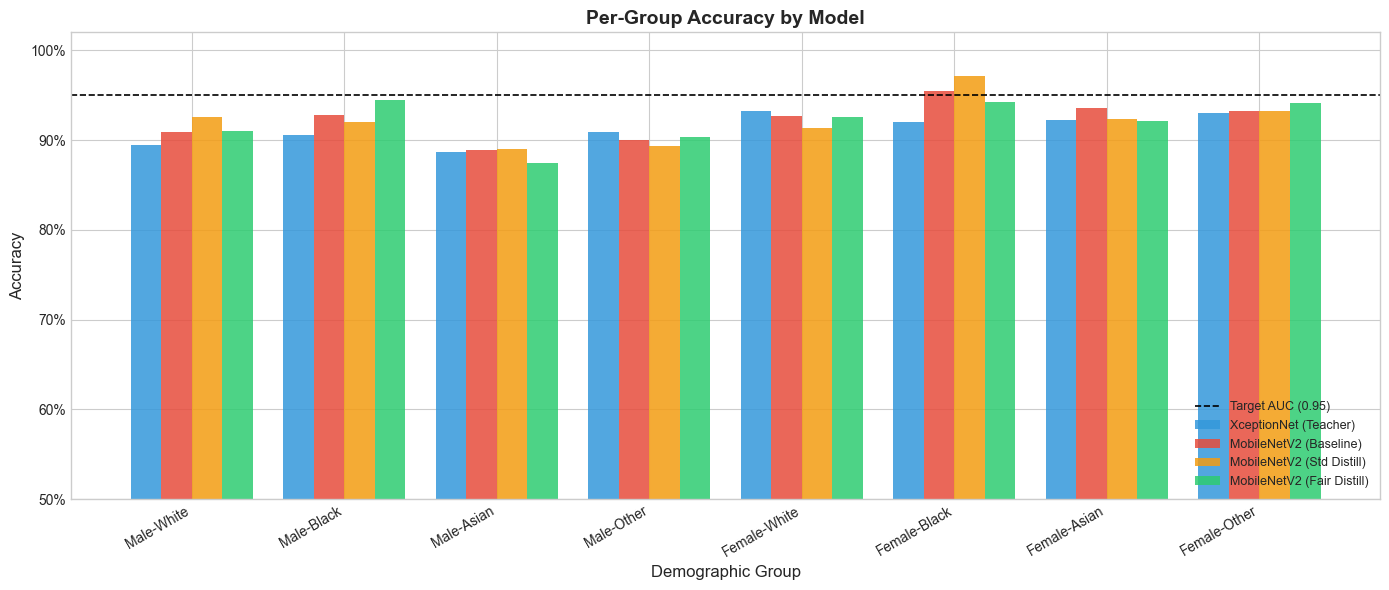

Saved: outputs/figures/per_group_accuracy.png


In [15]:
groups = DEMOGRAPHIC_GROUPS
x = np.arange(len(groups))
width = 0.2
model_names = list(all_results.keys())
bar_colors = ['#3498db','#e74c3c','#f39c12','#2ecc71']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, r) in enumerate(all_results.items()):
    accs = [r['fairness']['per_group_accuracy'].get(g, 0) for g in groups]
    bars = ax.bar(x + i*width, accs, width, label=name, color=bar_colors[i % len(bar_colors)], alpha=0.85)

# Target line
ax.axhline(y=0.95, color='black', linestyle='--', linewidth=1.2, label='Target AUC (0.95)')

ax.set_xlabel('Demographic Group', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Group Accuracy by Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(all_results)-1)/2)
ax.set_xticklabels(groups, rotation=30, ha='right')
ax.set_ylim(0.5, 1.02)
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'per_group_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/per_group_accuracy.png')


## 📉 Cell 12 — Fairness Gap Summary Chart

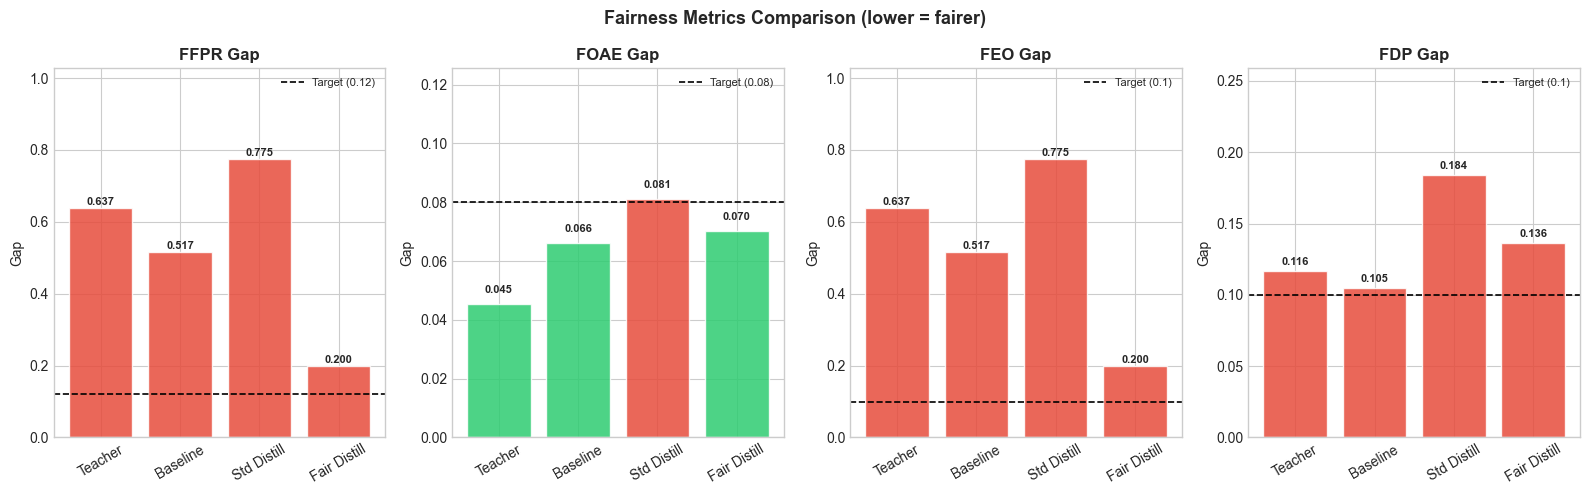

Saved: outputs/figures/fairness_gaps.png


In [16]:
metrics_labels = ['FFPR Gap', 'FOAE Gap', 'FEO Gap', 'FDP Gap']
metric_keys    = ['FFPR_gap', 'FOAE_gap', 'FEO_gap', 'FDP_gap']
targets        = [0.12, 0.08, 0.10, 0.10]

fig, axes = plt.subplots(1, len(metrics_labels), figsize=(16, 5))
fig.suptitle('Fairness Metrics Comparison (lower = fairer)', fontsize=13, fontweight='bold')

for ax, label, key, target in zip(axes, metrics_labels, metric_keys, targets):
    vals  = [all_results[n]['fairness'][key] for n in all_results]
    names = [n.split('(')[-1].replace(')','') for n in all_results]
    colors_bar = ['#2ecc71' if v <= target else '#e74c3c' for v in vals]
    ax.bar(names, vals, color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axhline(y=target, color='black', linestyle='--', linewidth=1.2, label=f'Target ({target})')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Gap')
    ax.set_ylim(0, max(vals)*1.3 + 0.02)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'fairness_gaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/fairness_gaps.png')


## 🔥 Cell 13 — Grad-CAM Heatmaps per Demographic Group

In [17]:
from src.explainability.gradcam import generate_gradcam_per_group

if fair_model is not None:
    print('Generating Grad-CAM heatmaps for Fair Student...')
    generate_gradcam_per_group(
        fair_model,
        os.path.join(SPLITS_DIR, 'test.csv'),
        num_samples_per_group=3,
        output_dir=GRADCAM_DIR,
        device=DEVICE
    )
    # Display saved heatmaps
    import glob
    from PIL import Image
    heatmap_files = sorted(glob.glob(os.path.join(GRADCAM_DIR, '*.png')))[:8]
    if heatmap_files:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle('Grad-CAM Heatmaps — Fair Student (per demographic group)', fontsize=13, fontweight='bold')
        for ax, fpath in zip(axes.flat, heatmap_files):
            img = Image.open(fpath)
            ax.imshow(img)
            ax.set_title(os.path.basename(fpath).replace('.png',''), fontsize=8)
            ax.axis('off')
        for ax in axes.flat[len(heatmap_files):]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR,'gradcam_grid.png'), dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('[SKIP] Fair student model not loaded.')


Generating Grad-CAM heatmaps for Fair Student...
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Female-White.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Female-Other.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Female-Asian.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Male-Asian.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Male-White.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Male-Other.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Male-Black.png
Saved: D:\M3 Projects\DeepFake_Research\outputs\gradcam\gradcam_Female-Black.png

Grad-CAM visualizations saved to: D:\M3 Projects\DeepFake_Research\outputs\gradcam


## ⚡ Cell 14 — Model Size & Inference Speed Profiling

In [18]:
import time

dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
WARMUP = 10
RUNS   = 100

rows = []
for name, model in models.items():
    if model is None:
        continue
    model.eval()
    size_mb = sum(p.nelement()*p.element_size() for p in model.parameters()) / 1e6
    params_m = sum(p.numel() for p in model.parameters()) / 1e6

    # Warmup
    with torch.no_grad():
        for _ in range(WARMUP):
            _ = model(dummy)

    # Timed runs
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(RUNS):
            _ = model(dummy)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) / RUNS * 1000

    rows.append({
        'Model':          name,
        'Params (M)':     f'{params_m:.1f}',
        'Size (MB)':      f'{size_mb:.1f}',
        'Inference (ms)': f'{elapsed_ms:.2f}',
        'FPS':            f'{1000/elapsed_ms:.0f}',
        '≤15 MB':         '✅' if size_mb <= 15 else '❌',
        '≤30 ms':         '✅' if elapsed_ms <= 30 else '❌',
    })

df_speed = pd.DataFrame(rows)
display(df_speed.style.set_caption('⚡ Model Efficiency Profiling').hide(axis='index'))
df_speed.to_csv(os.path.join(RESULTS_DIR,'speed_profiling.csv'), index=False)

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Efficiency Comparison', fontsize=13, fontweight='bold')

names_short = [n.split('(')[-1].replace(')','') for n in df_speed['Model']]
sizes  = df_speed['Size (MB)'].astype(float)
speeds = df_speed['Inference (ms)'].astype(float)

ax1.barh(names_short, sizes, color=bar_colors[:len(sizes)], alpha=0.85)
ax1.axvline(x=15, color='red', linestyle='--', label='Target (15 MB)')
ax1.set_xlabel('Model Size (MB)')
ax1.set_title('Model Size')
ax1.legend()

ax2.barh(names_short, speeds, color=bar_colors[:len(speeds)], alpha=0.85)
ax2.axvline(x=30, color='red', linestyle='--', label='Target (30 ms)')
ax2.set_xlabel('Inference Time (ms)')
ax2.set_title('Inference Speed')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'efficiency_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ All done! Results saved to outputs/results/ and outputs/figures/')


Model,Params (M),Size (MB),Inference (ms),FPS,≤15 MB,≤30 ms
XceptionNet (Teacher),21.9,87.4,4.47,224,❌,✅
MobileNetV2 (Baseline),2.6,10.2,5.42,185,✅,✅
MobileNetV2 (Std Distill),2.6,10.2,7.22,138,✅,✅
MobileNetV2 (Fair Distill),2.6,10.2,6.74,148,✅,✅



✅ All done! Results saved to outputs/results/ and outputs/figures/
